In [24]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.3

In [25]:
import kagglehub
briscdataset_brisc2025_path = kagglehub.dataset_download('briscdataset/brisc2025')
print('Data source import complete.')

Data source import complete.


In [26]:
import os, glob, random, warnings, hashlib
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [27]:
DATA_ROOT = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"

CLS_TRAIN_DIR  = os.path.join(DATA_ROOT, "classification_task", "train")
CLS_TEST_DIR   = os.path.join(DATA_ROOT, "classification_task", "test")

SEG_TRAIN_IMG  = os.path.join(DATA_ROOT, "segmentation_task", "train", "images")
SEG_TRAIN_MASK = os.path.join(DATA_ROOT, "segmentation_task", "train", "masks")
SEG_TEST_IMG   = os.path.join(DATA_ROOT, "segmentation_task", "test",  "images")
SEG_TEST_MASK  = os.path.join(DATA_ROOT, "segmentation_task", "test",  "masks")

CLASS_NAMES  = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)
IMG_SIZE     = 224

In [28]:
def build_cls_df(root_dir):
    rows = []
    for cls_name in CLASS_NAMES:
        cls_dir = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        for ext in ("*.jpg", "*.png", "*.jpeg"):
            for fpath in glob.glob(os.path.join(cls_dir, ext)):
                rows.append({"filepath": fpath, "label_name": cls_name, "label": CLASS_TO_IDX[cls_name]})
    return pd.DataFrame(rows)

cls_full_df = build_cls_df(CLS_TRAIN_DIR)
cls_test_df = build_cls_df(CLS_TEST_DIR)
print("Initial train:", len(cls_full_df), "| Initial test:", len(cls_test_df))

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("Checking duplicates...")
train_hashes = {file_hash(p): p for p in cls_full_df["filepath"]}
duplicates   = [p for p in cls_test_df["filepath"] if file_hash(p) in train_hashes]
print("Duplicates found:", len(duplicates))

cls_test_df = cls_test_df[~cls_test_df["filepath"].isin(duplicates)].reset_index(drop=True)
print("Test after cleaning:", len(cls_test_df))

cls_train_df, cls_val_df = train_test_split(
    cls_full_df, test_size=0.2, stratify=cls_full_df["label"], random_state=SEED
)
print("Train:", len(cls_train_df), "| Val:", len(cls_val_df))

Initial train: 5000 | Initial test: 1000
Checking duplicates...
Duplicates found: 7
Test after cleaning: 993
Train: 4000 | Val: 1000


In [29]:
def build_seg_df(img_dir, mask_dir):
    rows = []
    for img_path in sorted(glob.glob(os.path.join(img_dir, "*.jpg"))):
        stem      = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, stem + ".png")
        if os.path.exists(mask_path):
            rows.append({"img_path": img_path, "mask_path": mask_path})
    return pd.DataFrame(rows)

seg_train_df = build_seg_df(SEG_TRAIN_IMG, SEG_TRAIN_MASK)
seg_test_df  = build_seg_df(SEG_TEST_IMG,  SEG_TEST_MASK)
print("Seg train:", len(seg_train_df), "| Seg test:", len(seg_test_df))

Seg train: 3933 | Seg test: 860


In [30]:
#augmented BRISC + CLAHE 
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ToRGB(),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.ToRGB(),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [31]:
class BrainClassDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, int(row["label"])


class BrainSegDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row["img_path"])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)
        if self.transform:
            aug       = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        return img, mask.long()

In [32]:
class_counts   = cls_train_df['label'].value_counts().sort_index().values
class_weights  = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for label in cls_train_df['label'].values]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

cls_train_ds = BrainClassDataset(cls_train_df, train_aug)
cls_val_ds   = BrainClassDataset(cls_val_df,   test_aug)
cls_test_ds  = BrainClassDataset(cls_test_df,  test_aug)

cls_train_dl = DataLoader(cls_train_ds, batch_size=32, sampler=sampler,  num_workers=2, pin_memory=True)
cls_val_dl   = DataLoader(cls_val_ds,   batch_size=32, shuffle=False,     num_workers=2, pin_memory=True)
cls_test_dl  = DataLoader(cls_test_ds,  batch_size=32, shuffle=False,     num_workers=2, pin_memory=True)

seg_train_ds = BrainSegDataset(seg_train_df, train_aug)
seg_test_ds  = BrainSegDataset(seg_test_df,  test_aug)

seg_train_dl = DataLoader(seg_train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
seg_test_dl  = DataLoader(seg_test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

In [33]:
def set_resnet_grad(model, 
                    freeze_conv1=True,
                    freeze_bn1=True,
                    freeze_layer1=True,
                    freeze_layer2=True,
                    freeze_layer3=True,
                    freeze_layer4=True,
                    freeze_fc=False):
    """
    Freeze/unfreeze individual components of a torchvision ResNet.
    """
    # Stem
    for p in model.conv1.parameters():
        p.requires_grad = not freeze_conv1
    for p in model.bn1.parameters():
        p.requires_grad = not freeze_bn1

    # CE1 -> layer1
    for p in model.layer1.parameters():
        p.requires_grad = not freeze_layer1

    # CE2 -> layer2
    for p in model.layer2.parameters():
        p.requires_grad = not freeze_layer2

    # CE3 -> layer3
    for p in model.layer3.parameters():
        p.requires_grad = not freeze_layer3

    # CE4 -> layer4
    for p in model.layer4.parameters():
        p.requires_grad = not freeze_layer4

    # Classifier
    for p in model.fc.parameters():
        p.requires_grad = not freeze_fc

    # Print summary
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

def freeze_seg_encoder(model, model_name):
    for param in model.encoder.parameters():
        param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  [{model_name}] Frozen encoder – trainable: {trainable:,} / {total:,}")

def unfreeze_seg_encoder(model):
    for param in model.parameters():
        param.requires_grad = True
    print(f"  Unfrozen – all {sum(p.numel() for p in model.parameters()):,} params trainable.")

print("Freeze/unfreeze helpers defined.")

Freeze/unfreeze helpers defined.


In [34]:
def build_efficientnet_b0():
    m = models.efficientnet_b0(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True), nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_efficientnet_b1():
    m = models.efficientnet_b1(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True), nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_efficientnet_b3():
    m = models.efficientnet_b3(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True), nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_efficientnet_v2_s():
    m = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True), nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_resnet50():
    m = models.resnet50(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def build_mobilenet_v3():
    m = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def build_vgg16():
    m = models.vgg16_bn(weights="IMAGENET1K_V1")
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def build_convnext_tiny():
    m = models.convnext_tiny(weights="IMAGENET1K_V1")
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

CLS_REGISTRY = {
    "EfficientNet-B0":  build_efficientnet_b0,
    "EfficientNet-B1":  build_efficientnet_b1,
    "EfficientNet-B3":  build_efficientnet_b3,
    "EfficientNetV2-S": build_efficientnet_v2_s,
    "ResNet-50":        build_resnet50,
    "MobileNet-V3-S":   build_mobilenet_v3,
    "VGG-16-BN":        build_vgg16,
    "ConvNeXt-Tiny":    build_convnext_tiny,
}

SEG_REGISTRY = {
    "UNet-EffB0":          (smp.Unet,          "efficientnet-b0"),
    "UNet-ResNet34":       (smp.Unet,          "resnet34"),
    "UNetPP-EffB0":        (smp.UnetPlusPlus,  "efficientnet-b0"),
    "UNetPP-ResNet34":     (smp.UnetPlusPlus,  "resnet34"),
    "DeepLabV3P-EffB0":    (smp.DeepLabV3Plus, "efficientnet-b0"),
    "DeepLabV3P-ResNet50": (smp.DeepLabV3Plus, "resnet50"),
    "FPN-EffB0":           (smp.FPN,           "efficientnet-b0"),
    "MAnet-EffB0":         (smp.MAnet,         "efficientnet-b0"),
}

print("CLS models:", list(CLS_REGISTRY.keys()))
print("SEG models:", list(SEG_REGISTRY.keys()))

CLS models: ['EfficientNet-B0', 'EfficientNet-B1', 'EfficientNet-B3', 'EfficientNetV2-S', 'ResNet-50', 'MobileNet-V3-S', 'VGG-16-BN', 'ConvNeXt-Tiny']
SEG models: ['UNet-EffB0', 'UNet-ResNet34', 'UNetPP-EffB0', 'UNetPP-ResNet34', 'DeepLabV3P-EffB0', 'DeepLabV3P-ResNet50', 'FPN-EffB0', 'MAnet-EffB0']


In [35]:
CLS_MODEL_NAME = "ResNet-50"
SEG_MODEL_NAME = "UNet-EffB0"

LR_FROZEN    = 1e-3   # higher is fine — only the head/decoder trains
LR_UNFROZEN  = 1e-4   # lower to avoid destroying pretrained weights
WEIGHT_DECAY = 1e-4

CLS_EPOCHS_FROZEN = 25
SEG_EPOCHS_FROZEN = 1

CLS_EPOCHS_UNFRZ = 25  # used in the optional Phase 2 cells
SEG_EPOCHS_UNFRZ = 1

In [36]:
cls_criterion = nn.CrossEntropyLoss()

bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary")

def seg_criterion(pred, target):
    target_f = target.float().unsqueeze(1)
    return 0.5 * bce_loss(pred, target_f) + 0.5 * dice_loss(pred, target_f)

def dice_score(pred_logits, target):
    pred  = (torch.sigmoid(pred_logits) > 0.5).float()
    tgt   = target.float().unsqueeze(1)
    inter = (pred * tgt).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + tgt.sum(dim=(2, 3))
    return ((2 * inter + 1e-6) / (union + 1e-6)).mean().item()

In [37]:
def train_one_epoch_cls(model, loader, optimizer):
    model.train()
    total_loss = correct = n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = cls_criterion(out, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n

@torch.no_grad()
def eval_cls(model, loader):
    model.eval()
    correct = n = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        n       += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return correct / n, all_preds, all_labels

def train_one_epoch_seg(model, loader, optimizer):
    model.train()
    total_loss = total_dice = n = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        pred = model(imgs)
        loss = seg_criterion(pred, masks)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total_dice += dice_score(pred, masks) * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n, total_dice / n

@torch.no_grad()
def eval_seg(model, loader):
    model.eval()
    total_loss = total_dice = n = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        pred        = model(imgs)
        total_loss += seg_criterion(pred, masks).item() * imgs.size(0)
        total_dice += dice_score(pred, masks) * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n, total_dice / n

print("Helpers ready.")

Helpers ready.


In [38]:
cls_model = CLS_REGISTRY[CLS_MODEL_NAME]().to(DEVICE)

# ---------- CHANGE 1: use the new flexible freezing ----------
set_resnet_grad(cls_model,
                freeze_conv1=True,
                freeze_bn1=True,
                freeze_layer1=True,   # CE1 frozen
                freeze_layer2=True,   # CE2 frozen
                freeze_layer3=True,   # CE3 frozen
                freeze_layer4=True,
                freeze_fc=False)      # classifier unfrozen

# ---------- CHANGE 2: differential learning rates ----------
cls_optimizer = torch.optim.AdamW([
    {'params': cls_model.fc.parameters(), 'lr': LR_FROZEN},           # classifier
    {'params': cls_model.layer4.parameters(), 'lr': LR_UNFROZEN},
    {'params': cls_model.layer3.parameters(), 'lr': LR_UNFROZEN},
    {'params': cls_model.layer2.parameters(), 'lr': LR_UNFROZEN},
    {'params': cls_model.layer1.parameters(), 'lr': LR_UNFROZEN},
    {'params': cls_model.conv1.parameters(), 'lr': LR_UNFROZEN / 10}, # stem
    {'params': cls_model.bn1.parameters(), 'lr': LR_UNFROZEN / 10},
], weight_decay=WEIGHT_DECAY)

cls_history  = {"train_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print(f"\n── Phase 1 | {CLS_MODEL_NAME} | frozen backbone ──")
for epoch in range(1, CLS_EPOCHS_FROZEN + 1):
    tr_loss, tr_acc = train_one_epoch_cls(cls_model, cls_train_dl, cls_optimizer)
    val_acc, _, _   = eval_cls(cls_model, cls_val_dl)

    cls_history["train_loss"].append(tr_loss)
    cls_history["train_acc"].append(tr_acc)
    cls_history["val_acc"].append(val_acc)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cls_model.state_dict(), f"best_cls_frozen_{CLS_MODEL_NAME}.pth")
        flag = " ✓"

    print(f"[{CLS_MODEL_NAME}] {epoch:02d}/{CLS_EPOCHS_FROZEN}  "
          f"loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  val_acc={val_acc:.4f}{flag}")

print(f"\nBest val acc (frozen): {best_val_acc:.4f}")

Trainable params: 8,196 / 23,516,228 (0.03%)

── Phase 1 | ResNet-50 | frozen backbone ──
[ResNet-50] 01/25  loss=0.6404  tr_acc=0.7815  val_acc=0.8460 ✓
[ResNet-50] 02/25  loss=0.4259  tr_acc=0.8480  val_acc=0.8610 ✓
[ResNet-50] 03/25  loss=0.3715  tr_acc=0.8738  val_acc=0.8870 ✓
[ResNet-50] 04/25  loss=0.3274  tr_acc=0.8842  val_acc=0.8700
[ResNet-50] 05/25  loss=0.3221  tr_acc=0.8868  val_acc=0.8970 ✓
[ResNet-50] 06/25  loss=0.3330  tr_acc=0.8765  val_acc=0.8640
[ResNet-50] 07/25  loss=0.3158  tr_acc=0.8845  val_acc=0.8990 ✓
[ResNet-50] 08/25  loss=0.3080  tr_acc=0.8840  val_acc=0.9010 ✓
[ResNet-50] 09/25  loss=0.2770  tr_acc=0.9010  val_acc=0.9020 ✓
[ResNet-50] 10/25  loss=0.2961  tr_acc=0.8935  val_acc=0.9070 ✓
[ResNet-50] 11/25  loss=0.2764  tr_acc=0.8958  val_acc=0.8930
[ResNet-50] 12/25  loss=0.2685  tr_acc=0.9052  val_acc=0.9120 ✓
[ResNet-50] 13/25  loss=0.2543  tr_acc=0.9125  val_acc=0.9010
[ResNet-50] 14/25  loss=0.2609  tr_acc=0.9028  val_acc=0.9110
[ResNet-50] 15/25  loss=

In [39]:
arch, encoder = SEG_REGISTRY[SEG_MODEL_NAME]
seg_model     = arch(encoder_name=encoder, encoder_weights="imagenet",
                     in_channels=3, classes=1, activation=None).to(DEVICE)
freeze_seg_encoder(seg_model, SEG_MODEL_NAME)

seg_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, seg_model.parameters()),
    lr=LR_FROZEN, weight_decay=WEIGHT_DECAY
)

seg_history   = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}
best_val_dice = 0.0

print(f"\n── Phase 1 | {SEG_MODEL_NAME} | frozen encoder ──")
for epoch in range(1, SEG_EPOCHS_FROZEN + 1):
    tr_loss, tr_dice = train_one_epoch_seg(seg_model, seg_train_dl, seg_optimizer)
    vl_loss, vl_dice = eval_seg(seg_model, seg_test_dl)

    seg_history["train_loss"].append(tr_loss)
    seg_history["val_loss"].append(vl_loss)
    seg_history["train_dice"].append(tr_dice)
    seg_history["val_dice"].append(vl_dice)

    flag = ""
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(seg_model.state_dict(), f"best_seg_frozen_{SEG_MODEL_NAME}.pth")
        flag = " ✓"

    print(f"[{SEG_MODEL_NAME}] {epoch:02d}/{SEG_EPOCHS_FROZEN}  "
          f"tr_loss={tr_loss:.4f}  tr_dice={tr_dice:.4f}  "
          f"vl_loss={vl_loss:.4f}  vl_dice={vl_dice:.4f}{flag}")

print(f"\nBest val Dice (frozen): {best_val_dice:.4f}")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 150MB/s] 


  [UNet-EffB0] Frozen encoder – trainable: 2,243,921 / 6,251,469

── Phase 1 | UNet-EffB0 | frozen encoder ──
[UNet-EffB0] 01/1  tr_loss=0.2892  tr_dice=0.6029  vl_loss=0.1473  vl_dice=0.7058 ✓

Best val Dice (frozen): 0.7058


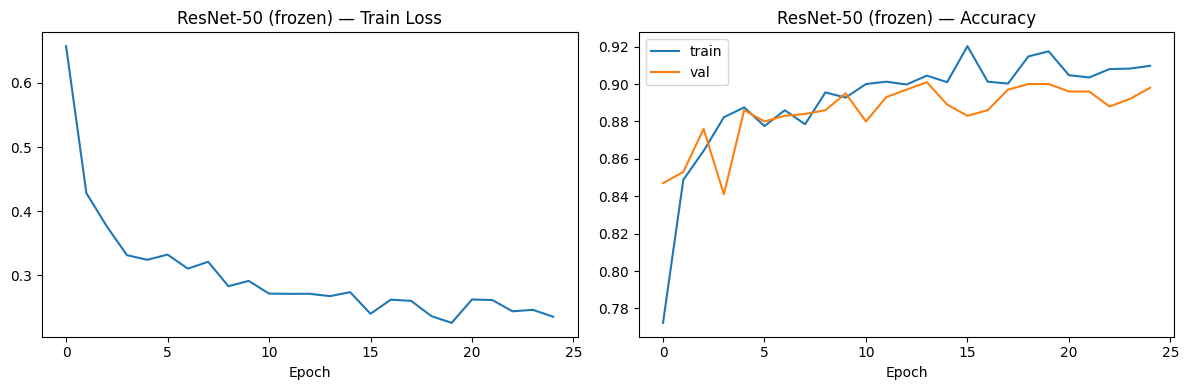


ResNet-50 (frozen)  |  Test accuracy: 0.8701

              precision    recall  f1-score   support

      glioma       0.94      0.82      0.88       254
  meningioma       0.83      0.75      0.79       304
    no_tumor       0.77      1.00      0.87       140
   pituitary       0.92      0.97      0.95       295

    accuracy                           0.87       993
   macro avg       0.86      0.89      0.87       993
weighted avg       0.87      0.87      0.87       993



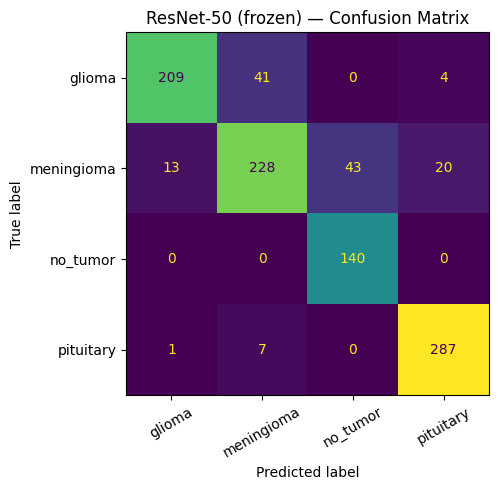

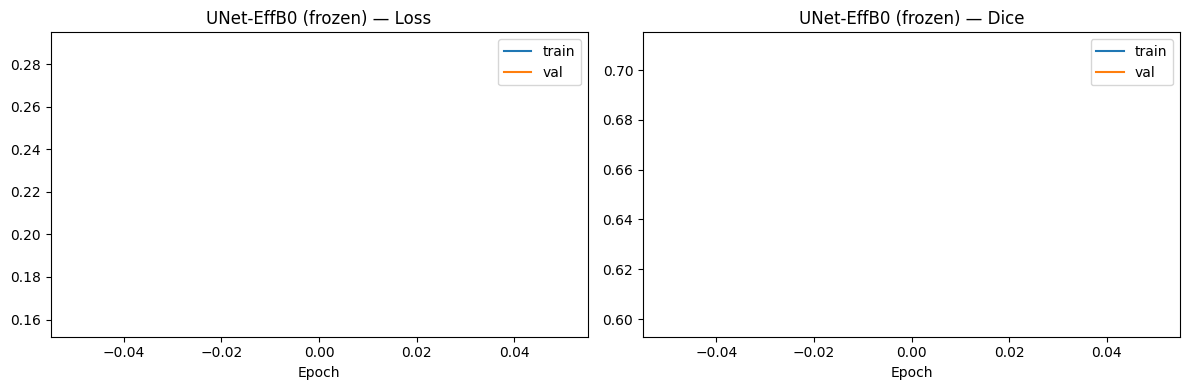

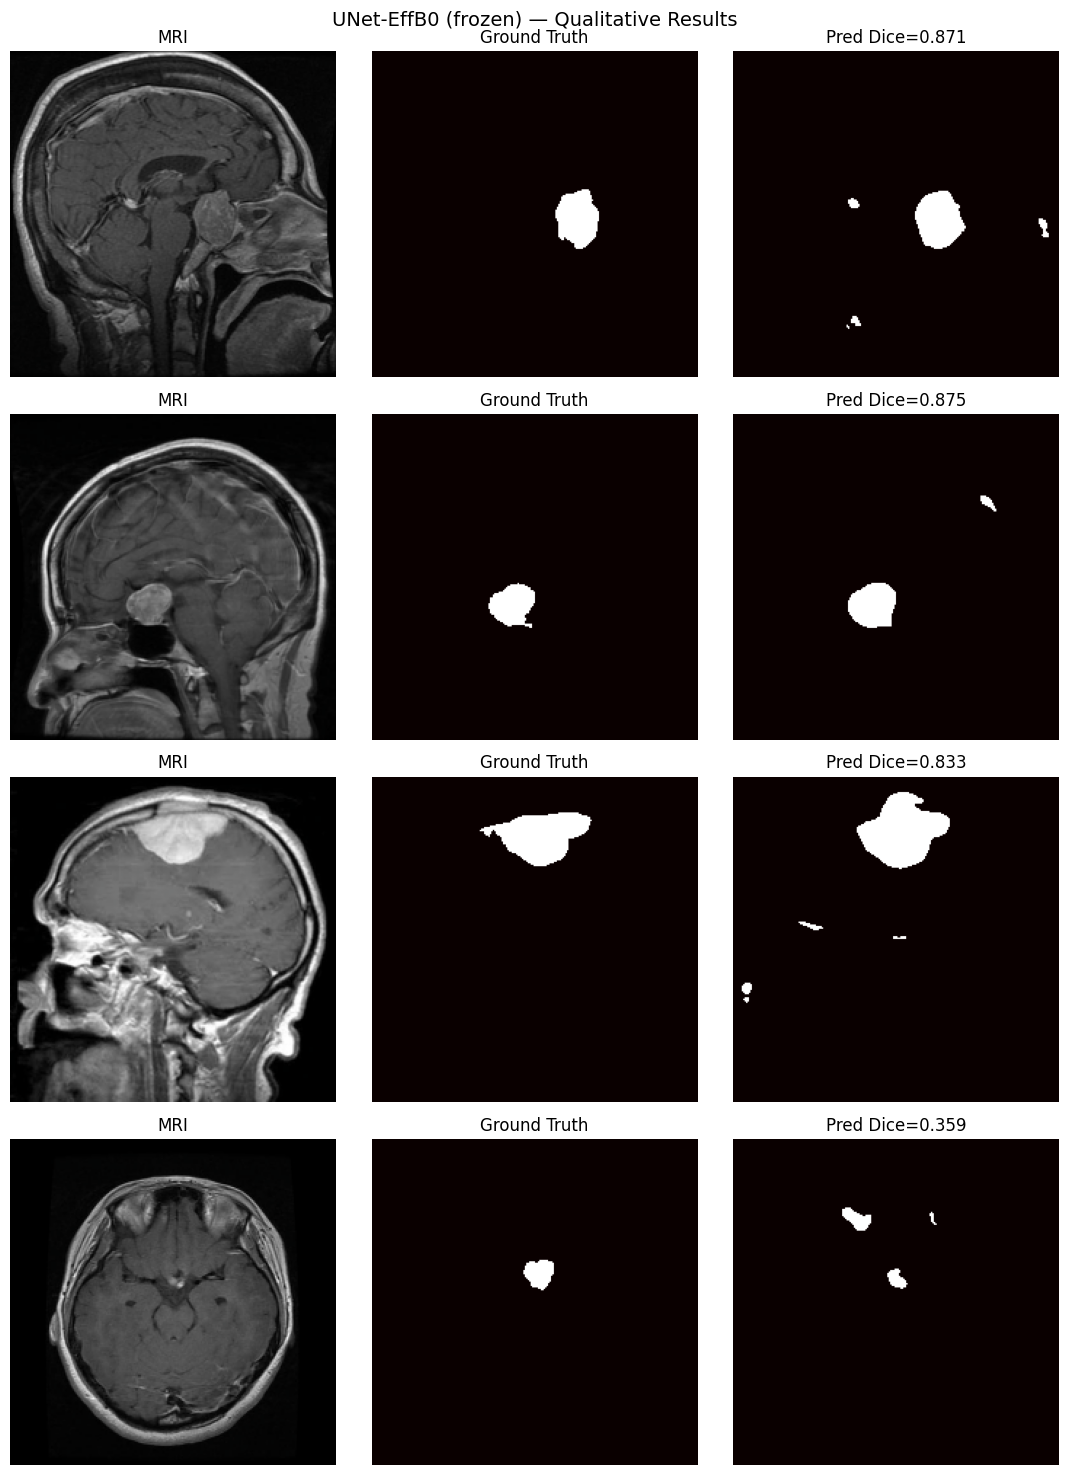

✅ Phase 1 done.


In [20]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

# Classification curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(cls_history["train_loss"])
ax1.set_title(f"{CLS_MODEL_NAME} (frozen) — Train Loss"); ax1.set_xlabel("Epoch")
ax2.plot(cls_history["train_acc"], label="train")
ax2.plot(cls_history["val_acc"],   label="val")
ax2.set_title(f"{CLS_MODEL_NAME} (frozen) — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout(); plt.savefig(f"cls_curves_frozen_{CLS_MODEL_NAME}.png", dpi=150); plt.show()

# Classification report + confusion matrix
cls_model.load_state_dict(torch.load(f"best_cls_frozen_{CLS_MODEL_NAME}.pth"))
test_acc, preds, labels_ = eval_cls(cls_model, cls_test_dl)
print(f"\n{CLS_MODEL_NAME} (frozen)  |  Test accuracy: {test_acc:.4f}\n")
print(classification_report(labels_, preds, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(labels_, preds), display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=False, xticks_rotation=30)
ax.set_title(f"{CLS_MODEL_NAME} (frozen) — Confusion Matrix")
plt.tight_layout(); plt.savefig(f"cls_cm_frozen_{CLS_MODEL_NAME}.png", dpi=150); plt.show()

# Segmentation curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(seg_history["train_loss"], label="train"); ax1.plot(seg_history["val_loss"], label="val")
ax1.set_title(f"{SEG_MODEL_NAME} (frozen) — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(seg_history["train_dice"], label="train"); ax2.plot(seg_history["val_dice"], label="val")
ax2.set_title(f"{SEG_MODEL_NAME} (frozen) — Dice"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout(); plt.savefig(f"seg_curves_frozen_{SEG_MODEL_NAME}.png", dpi=150); plt.show()

# Segmentation qualitative spot-check
seg_model.load_state_dict(torch.load(f"best_seg_frozen_{SEG_MODEL_NAME}.pth"))
sample_ds = BrainSegDataset(seg_test_df.sample(4, random_state=7).reset_index(drop=True), test_aug)

seg_model.eval()
fig, axes = plt.subplots(4, 3, figsize=(11, 15))
with torch.no_grad():
    for i in range(4):
        img_t, mask_t = sample_ds[i]
        pred   = torch.sigmoid(seg_model(img_t.unsqueeze(0).to(DEVICE))).squeeze().cpu().numpy()
        img_np = (img_t.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1)
        dice   = (2 * ((pred > 0.5) * mask_t.numpy()).sum() + 1e-6) / \
                 ((pred > 0.5).sum() + mask_t.numpy().sum() + 1e-6)
        axes[i, 0].imshow(img_np);                     axes[i, 0].set_title("MRI")
        axes[i, 1].imshow(mask_t.numpy(), cmap="hot"); axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(pred > 0.5,     cmap="hot"); axes[i, 2].set_title(f"Pred Dice={dice:.3f}")
        for ax in axes[i]: ax.axis("off")
plt.suptitle(f"{SEG_MODEL_NAME} (frozen) — Qualitative Results", fontsize=14)
plt.tight_layout(); plt.savefig(f"seg_qual_frozen_{SEG_MODEL_NAME}.png", dpi=150, bbox_inches="tight"); plt.show()

print("✅ Phase 1 done.")